# PREPROCESSING PIPELINE — ANALISIS SENTIMEN MBG
# ============================================================
# Proyek  : Skripsi Ilmal Yakin Nurahman (224260028)
# Judul   : Perbandingan LSTM dan Bi-LSTM untuk Analisis Sentimen Program Makan Bergizi Gratis
# Tahapan : Cleaning → Case Folding → Normalisasi Slang → Tokenisasi → Stopword Removal → Stemming →  Filter Token Pendek → Simpan
# Platform: Google Colab
# ============================================================

# BAGIAN 0 — IMPORT DAN INSTALASI

In [ ]:
# ============================================================
# BAGIAN 0 — IMPORT DAN INSTALASI
# ============================================================

import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Install library Bahasa Indonesia
!pip install Sastrawi -q

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print("✅ Semua library berhasil diimport")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.9 MB/s eta 0:00:00
✅ Semua library berhasil diimport


# BAGIAN 1 — LOAD DATA

In [ ]:
# BAGIAN 1 — LOAD DATA (DIPERBAIKI)
from google.colab import drive
drive.mount('/content/drive')

DRIVE_FOLDER = '/content/drive/MyDrive/skripsi_mbg'

# PERBAIKAN: gunakan dataset gabungan hasil crawl baru
INPUT_PATH  = f'{DRIVE_FOLDER}/data/data_final/dataset_mbg_raw_gabungan.csv'
OUTPUT_CSV  = f'{DRIVE_FOLDER}/data/processed/dataset_mbg_preprocessed.csv'
OUTPUT_PKL  = f'{DRIVE_FOLDER}/data/processed/dataset_mbg_preprocessed.pkl'
OUTPUT_FIG  = f'{DRIVE_FOLDER}/figures/preprocessing_analysis.png'

df = pd.read_csv(INPUT_PATH)
print(f"Total tweets dimuat: {len(df)}")  # harus 2320
TOTAL_AWAL = len(df)

Mounted at /content/drive
Total tweets dimuat: 2320


# BAGIAN 2 — DEFINISI KONFIGURASI PREPROCESSING

In [ ]:
# ============================================================
# BAGIAN 2 — DEFINISI KONFIGURASI PREPROCESSING
# ============================================================
# Semua konfigurasi dikumpulkan di satu tempat agar
# mudah dimodifikasi tanpa mengubah fungsi-fungsi di bawah
# ----------------------------------------------------------
# 2A. KAMUS NORMALISASI SLANG / KATA TIDAK BAKU
# ----------------------------------------------------------
# Sumber: kombinasi kamus umum + temuan manual dari data MBG
KAMUS_SLANG = {
# Kata ganti & konjungsi informal (tetap)
'yg':'yang', 'dgn':'dengan', 'utk':'untuk',
'krn':'karena', 'tp':'tapi', 'jg':'juga',
'pd':'pada', 'dr':'dari', 'sm':'sama',
'kpd':'kepada', 'ttg':'tentang',
# Kata kerja & sifat informal (tetap)
'sdh':'sudah', 'udh':'sudah', 'udah':'sudah',
'blm':'belum', 'lg':'lagi', 'jd':'jadi',
'bs':'bisa', 'hrs':'harus',
# Negasi informal (tetap)
'gak':'tidak', 'ga':'tidak', 'ngga':'tidak',
'gk':'tidak', 'tdk':'tidak', 'tak':'tidak',
'nggak':'tidak', 'enggak':'tidak',
# TAMBAHAN: ekspresi negatif/sarkasme yang sering di Twitter
'hadeh' : 'haduh',
'astaga' : 'astaga',
'parah' : 'parah',
'zonk' : 'gagal',
'kepo' : 'penasaran',
'bodo' : 'bodoh',
'mah' : '', # partikel sunda tanpa makna
'sih' : '', # partikel penegas tanpa makna
'deh' : '',
'dong' : '',
'loh' : '',
'kok' : 'mengapa',
'wkwk' : '', # tawa, tidak bermakna untuk sentimen
'wkwkwk' : '',
'haha' : '',
'hehe' : '',
'njir' : 'tidak bagus',
'anjir' : 'tidak bagus',
'buset' : 'tidak percaya',
'gilak' : 'tidak percaya',
# Noise (tetap)
'rt':'', 'amp':'', 'gt':'', 'lt':'', 'ny':'',
}

## 2B. KATA YANG DIKECUALIKAN DARI STEMMING

In [ ]:
# ----------------------------------------------------------
# 2B. KATA YANG DIKECUALIKAN DARI STEMMING
# ----------------------------------------------------------
# Sastrawi terkadang mengubah kata penting menjadi salah:
# Contoh: 'pemerintah' → 'perintah' (makna berubah!)
STEMMING_EXCEPTIONS = {
# Entitas & nama program (tetap)
'pemerintah', 'indonesia', 'mbg', 'bumn', 'umkm',
'pln', 'bgn', 'sppg', 'sekolah', 'stunting',
'anggaran', 'distribusi', 'presiden', 'menteri', 'nasional',
'program', 'kebijakan', 'nutrisi', 'balita', 'pelajar',
# TAMBAHAN: kata negatif yang sering salah di-stem Sastrawi
'keracunan', # → jangan jadi 'racun'
'pencitraan', # → jangan jadi 'citra'
'korupsi', # → jangan jadi 'korup'
'pemborosan', # → jangan jadi 'boros'
'penolakan', # → jangan jadi 'tolak'
'kekecewaan', # → jangan jadi 'kecewa'
'keterlambatan',
'ketidakmerataan',
'penyimpangan',
}

## 2C. CUSTOM STOPWORD KONTEKSTUAL MBG

In [ ]:
# ----------------------------------------------------------
# 2C. CUSTOM STOPWORD KONTEKSTUAL MBG
# ----------------------------------------------------------
# Kata-kata ini adalah "topik identifier" — lolos filter
# relevansi KARENA kata ini ada, tapi tidak membantu model
# membedakan sentimen positif vs negatif vs netral
CUSTOM_STOPWORDS = {
    'bergizi', 'gratis', 'gizi',
    'makanbergizigratis', 'bergizigratis',
    'makangratis', 'makansianggratis',
    'programmbg',
    'amp', 'rt', 'gt', 'lt', 'ny', 'nya',

    # TAMBAHAN: token noise yang teridentifikasi dari top 20
    'mbg',          # rank 2 — topik identifier, bukan pembeda sentimen
    'program',      # rank 3 — terlalu generik
    'siang',        # rank 10 — dari 'makan siang', tidak bermakna sendiri
    'saja',         # hasil normalisasi 'aja'
    'aja',          # partikel tanpa makna
    'angka',        # artefak dari penggantian digit — HAPUS jika fix 1 diterapkan
    'cegahstunting',# hashtag gagal dipisah
    'planeconomy',  # terlihat di sample tweet 2
}
# Gabungkan stopword Bahasa Indonesia bawaan + custom
_stop_factory = StopWordRemoverFactory()
STOPWORDS_ID = set(_stop_factory.get_stop_words())
ALL_STOPWORDS = STOPWORDS_ID | CUSTOM_STOPWORDS
# Inisialisasi stemmer (dilakukan sekali di sini)
STEMMER = StemmerFactory().create_stemmer()
print("✅ Konfigurasi preprocessing berhasil dimuat")
print(f" Entri kamus slang : {len(KAMUS_SLANG)} kata")
print(f" Stemming exceptions : {len(STEMMING_EXCEPTIONS)} kata")
print(f" Total stopwords : {len(ALL_STOPWORDS)} kata")

✅ Konfigurasi preprocessing berhasil dimuat
 Entri kamus slang : 52 kata
 Stemming exceptions : 29 kata
 Total stopwords : 144 kata


# BAGIAN 3 — FUNGSI-FUNGSI PREPROCESSING

In [ ]:
# ============================================================
# BAGIAN 3 — FUNGSI-FUNGSI PREPROCESSING
# ============================================================

def tahap1_cleaning(text):
    if not isinstance(text, str):
        return ''

    # Ekstrak hashtag bermakna (tetap)
    def ekstrak_hashtag(match):
        tag = match.group(0)[1:]
        tag = re.sub(r'([a-z])([A-Z])', r'\1 \2', tag)
        tag = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1 \2', tag)
        # TAMBAHAN: pisahkan jika semua lowercase CamelCase seperti 'cegahstunting'
        # tidak bisa dibantu regex — biarkan, ini limitasi tanpa NLP tokenizer
        return tag

    text = re.sub(r'#\w+', ekstrak_hashtag, text)

    # Hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Hapus mention
    text = re.sub(r'@\w+', '', text)

    # PERBAIKAN: ganti tanda hubung dan underscore dengan spasi
    # SEBELUM hapus karakter khusus
    # Ini menangani: 'anak-anak' → 'anak anak' (bukan 'anakanak')
    text = re.sub(r'[-_/]', ' ', text)

    # Hapus karakter khusus (setelah tanda hubung sudah jadi spasi)
    text = re.sub(r'[^\w\s]', '', text)

    # Hapus angka — PERBAIKAN: hapus saja, tidak perlu jadi token ANGKA
    # karena token 'angka' yang seragam justru jadi noise (rank 4, 930x)
    text = re.sub(r'\d+', '', text)

    # Hapus karakter non-Latin
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Normalisasi whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def tahap2_case_folding(text):
    """
    TAHAP 2: Case Folding — Mengubah semua huruf menjadi lowercase.
    Dilakukan SETELAH cleaning agar proses regex di tahap 1
    tidak perlu mempertimbangkan variasi huruf besar/kecil.
    Contoh: "Makan Bergizi Gratis" → "makan bergizi gratis"
    Args:
        text (str): Teks yang sudah melalui cleaning
    Returns:
        str: Teks dalam huruf kecil semua
    """
    return text.lower()

def tahap3_normalisasi_slang(text):
    """
    TAHAP 3: Normalisasi — Mengubah kata tidak baku ke bentuk formal.
    Mengganti singkatan dan kata informal Bahasa Indonesia
    menggunakan KAMUS_SLANG yang sudah didefinisikan di Bagian 2.
    Contoh:
        'yg' → 'yang'
        'gak' → 'tidak'
        'udh' → 'sudah'
        'rt' → '' (dihapus)
    Args:
        text (str): Teks yang sudah di-lowercase
    Returns:
        str: Teks dengan kata-kata yang sudah dinormalisasi
    """
    words = text.split()
    result = []
    for word in words:
        pengganti = KAMUS_SLANG.get(word, word)
        if pengganti.strip():  # skip jika hasil penggantian kosong
            result.append(pengganti)
    return ' '.join(result)

def tahap4_tokenisasi(text):
    """
    TAHAP 4: Tokenisasi — Memecah teks menjadi list token/kata.
    Tokenisasi dilakukan dengan split berdasarkan whitespace.
    Pendekatan ini cukup untuk Bahasa Indonesia karena kata
    umumnya dipisahkan spasi.
    Contoh:
        "program makan bergizi bagus" →
        ["program", "makan", "bergizi", "bagus"]
    Args:
        text (str): Teks yang sudah dinormalisasi
    Returns:
        list: List berisi token/kata individual
    """
    return text.split()

def tahap5_stopword_removal(tokens):
    """
    TAHAP 5: Stopword Removal — Menghapus kata yang tidak bermakna.
    Menghapus dua kategori kata:
    1. Stopword Bahasa Indonesia bawaan (dari library Sastrawi)
       Contoh: di, dan, yang, untuk, ini, itu, dari
    2. Custom stopword kontekstual MBG (dari CUSTOM_STOPWORDS)
       Contoh: mbg, makan, bergizi, gratis (terlalu umum)
    Filter tambahan: token dengan panjang ≤ 1 karakter juga dihapus
    karena tidak memiliki makna linguistik.
    Args:
        tokens (list): List token hasil tokenisasi
    Returns:
        list: List token yang sudah bersih dari stopword
    """
    return [
        token for token in tokens
        if token not in ALL_STOPWORDS
        and len(token) > 1          # buang token 1 karakter
        and token.strip() != ''     # ← TAMBAHAN: buang token kosong
    ]

def tahap6_stemming(tokens):
    """
    TAHAP 6: Stemming — Mengubah kata ke bentuk dasar (root word).
    Menggunakan library Sastrawi untuk Bahasa Indonesia.
    Kata-kata dalam STEMMING_EXCEPTIONS tidak di-stem untuk
    mencegah perubahan makna yang tidak diinginkan.
    Contoh normal:
        'mendukung' → 'dukung'
        'keracunan' → 'racun'
        'penerapan' → 'terap'
    Contoh exception (tidak di-stem):
        'pemerintah' → 'pemerintah' (bukan 'perintah')
        'indonesia' → 'indonesia'
    Args:
        tokens (list): List token setelah stopword removal
    Returns:
        list: List token dalam bentuk kata dasar
    """
    result = []
    for token in tokens:
        if token in STEMMING_EXCEPTIONS:
            result.append(token)  # pertahankan apa adanya
        else:
            result.append(STEMMER.stem(token))
    return result

print("✅ Semua fungsi preprocessing berhasil didefinisikan")

✅ Semua fungsi preprocessing berhasil didefinisikan


# Fix 3 Pengganti bagian 4,5 dan 7

In [ ]:
# Jalankan ulang dari Bagian 4 saja — efisien, tidak perlu install ulang
# Karena perubahan ada di fungsi cleaning dan stopword

print("🔄 Menjalankan ulang pipeline dengan perbaikan...")

# Reset ke data mentah
df = pd.read_csv(INPUT_PATH)
TOTAL_AWAL = len(df)

# Jalankan ulang semua tahap
df['text_cleaned']   = df['full_text'].apply(tahap1_cleaning)
df['text_casefolded']= df['text_cleaned'].apply(tahap2_case_folding)
df['text_normalized']= df['text_casefolded'].apply(tahap3_normalisasi_slang)
df['tokens']         = df['text_normalized'].apply(tahap4_tokenisasi)
df['tokens']         = df['tokens'].apply(tahap5_stopword_removal)
df['tokens']         = df['tokens'].apply(tahap6_stemming)
df['text_final']     = df['tokens'].apply(lambda t: ' '.join(t))

# Filter
df = df.drop_duplicates(subset=['text_final']).reset_index(drop=True)
df = df[df['text_final'].str.strip() != '']
df = df[df['tokens'].apply(len) >= 4].reset_index(drop=True)

# Verifikasi
anakanak   = sum(1 for t in df['tokens'] if 'anakanak' in t)
angka_tok  = sum(1 for t in df['tokens'] if 'angka' in t)
keracunan  = sum(1 for t in df['tokens'] if 'keracunan' in t)

print(f"\nTotal tweet final : {len(df)}")
print(f"'anakanak'        : {anakanak}  (target: 0)")
print(f"'angka' token     : {angka_tok} (target: 0)")
print(f"'keracunan'       : {keracunan} (target: > 500)")

# Simpan ulang
df_output = df[['full_text', 'text_final', 'tokens']].copy()
df_output.to_csv(OUTPUT_CSV, index=False, encoding='utf-8')
with open(OUTPUT_PKL, 'wb') as f:
    pickle.dump(df_output, f)

print(f"\n✅ File tersimpan ulang: {len(df_output)} baris")

🔄 Menjalankan ulang pipeline dengan perbaikan...

Total tweet final : 2301
'anakanak'        : 0  (target: 0)
'angka' token     : 0 (target: 0)
'keracunan'       : 581 (target: > 500)

✅ File tersimpan ulang: 2301 baris


# BAGIAN 4 — JALANKAN PIPELINE

# BAGIAN 6 — ANALISIS DAN VISUALISASI HASIL


ANALISIS HASIL PREPROCESSING

Statistik Token:
  Total jumlah token    : 43,545
  Jumlah unique token   : 6,588
  Rata-rata token/tweet : 18.9
  Ratio unique/total    : 0.151
  Min token/tweet       : 4
  Max token/tweet       : 42
  Median token/tweet    : 19

Top 20 Token Paling Sering Muncul:
   1. 'makan' : 2060 kemunculan
   2. 'anak' : 895 kemunculan
   3. 'keracunan' : 633 kemunculan
   4. 'sekolah' : 469 kemunculan
   5. 'jadi' : 438 kemunculan
   6. 'indonesia' : 369 kemunculan
   7. 'banyak' : 274 kemunculan
   8. 'siswa' : 262 kemunculan
   9. 'buat' : 256 kemunculan
  10. 'sehat' : 240 kemunculan
  11. 'bukan' : 234 kemunculan
  12. 'lebih' : 219 kemunculan
  13. 'prabowo' : 215 kemunculan
  14. 'anggaran' : 212 kemunculan
  15. 'dukung' : 194 kemunculan
  16. 'mau' : 182 kemunculan
  17. 'sama' : 181 kemunculan
  18. 'pemerintah' : 177 kemunculan
  19. 'rakyat' : 177 kemunculan
  20. 'apa' : 166 kemunculan


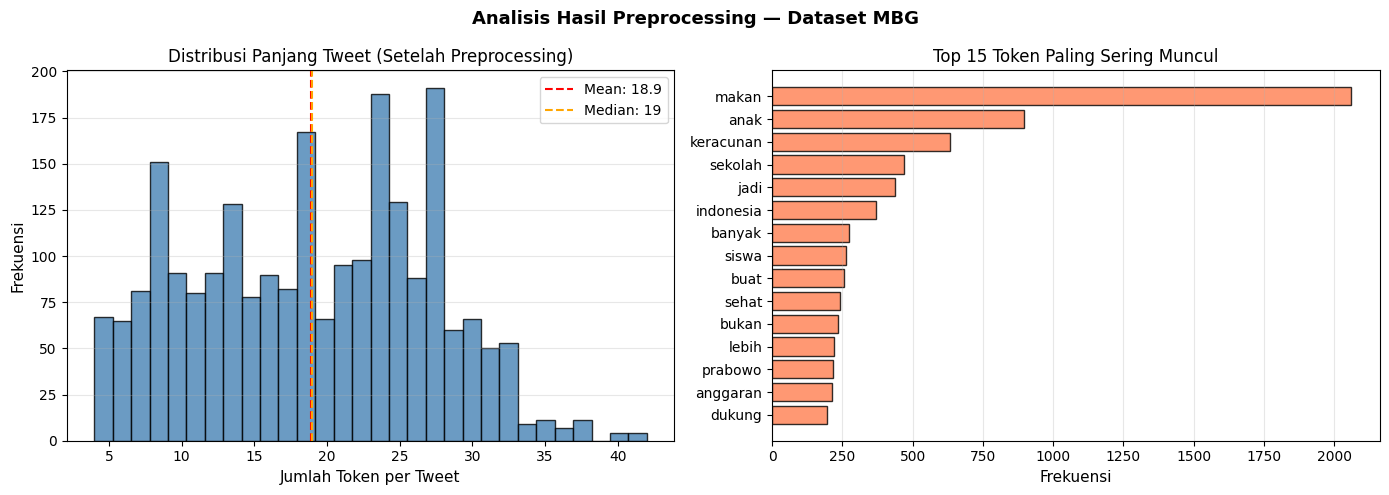


✅ Visualisasi tersimpan: /content/drive/MyDrive/skripsi_mbg/figures/preprocessing_analysis.png


In [ ]:
# ============================================================
# BAGIAN 6 — ANALISIS DAN VISUALISASI HASIL
# ============================================================

print("\n" + "=" * 60)
print("ANALISIS HASIL PREPROCESSING")
print("=" * 60)

# Kumpulkan semua token
all_tokens   = [t for tokens in df['tokens'] for t in tokens]
token_counts = df['tokens'].apply(len)
token_freq   = Counter(all_tokens)
top20        = token_freq.most_common(20)

print(f"\nStatistik Token:")
print(f"  Total jumlah token    : {len(all_tokens):,}")
print(f"  Jumlah unique token   : {len(set(all_tokens)):,}")
print(f"  Rata-rata token/tweet : {len(all_tokens)/len(df):.1f}")
print(f"  Ratio unique/total    : {len(set(all_tokens))/len(all_tokens):.3f}")
print(f"  Min token/tweet       : {token_counts.min()}")
print(f"  Max token/tweet       : {token_counts.max()}")
print(f"  Median token/tweet    : {token_counts.median():.0f}")

print(f"\nTop 20 Token Paling Sering Muncul:")
for idx, (token, freq) in enumerate(top20, 1):
    print(f"  {idx:2d}. '{token}' : {freq} kemunculan")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi panjang tweet
axes[0].hist(token_counts, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Jumlah Token per Tweet', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)
axes[0].set_title('Distribusi Panjang Tweet (Setelah Preprocessing)', fontsize=12)
axes[0].axvline(token_counts.mean(),   color='red',    linestyle='--',
                label=f'Mean: {token_counts.mean():.1f}')
axes[0].axvline(token_counts.median(), color='orange', linestyle='--',
                label=f'Median: {token_counts.median():.0f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Top 15 token
top15_tokens = dict(token_freq.most_common(15))
axes[1].barh(list(top15_tokens.keys()), list(top15_tokens.values()),
             color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Frekuensi', fontsize=11)
axes[1].set_title('Top 15 Token Paling Sering Muncul', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Analisis Hasil Preprocessing — Dataset MBG', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Visualisasi tersimpan: {OUTPUT_FIG}")


# BAGIAN 8 — SUMMARY AKHIR

In [ ]:
# ============================================================
# BAGIAN 8 — SUMMARY AKHIR
# ============================================================

print("\n" + "=" * 60)
print("SUMMARY PREPROCESSING")
print("=" * 60)

summary = {
    'Dataset Awal'           : TOTAL_AWAL,
    'Setelah Filter'         : len(df),
    'Data Dihapus'           : TOTAL_AWAL - len(df),
    'Persentase Tersisa'     : f"{len(df)/TOTAL_AWAL*100:.2f}%",
    'Total Token'            : len(all_tokens),
    'Total Unique Token'     : len(set(all_tokens)),
    'Rata-rata Token/Tweet'  : f"{len(all_tokens)/len(df):.1f}",
    'Min Token/Tweet'        : token_counts.min(),
    'Max Token/Tweet'        : token_counts.max(),
}

for key, value in summary.items():
    print(f"  {key:.<35} {value}")

# Cek kata 'makan' masih ada setelah preprocessing
makan_count = sum(1 for tokens in df['tokens'] if 'makan' in tokens)
print(f"\n✅ Verifikasi: 'makan' muncul di {makan_count} tweet")
print(f"   (seharusnya > 0, jika 0 berarti masih ada bug stopword)")

# Cek 'keracunan' tidak terstem jadi 'racun'
keracunan_count = sum(1 for tokens in df['tokens'] if 'keracunan' in tokens)
racun_count     = sum(1 for tokens in df['tokens'] if 'racun' in tokens)
print(f"\n✅ Verifikasi stemming exception:")
print(f"   'keracunan' : {keracunan_count} tweet")
print(f"   'racun'     : {racun_count} tweet")
print(f"   (idealnya keracunan >> racun)")

# Cek tidak ada token 'anakanak'
anakanak = sum(1 for tokens in df['tokens'] if 'anakanak' in tokens)
print(f"\n✅ Verifikasi bug CamelCase: 'anakanak' = {anakanak} tweet")
print(f"   (harus 0 setelah perbaikan)")

# Sample hasil akhir
print("\n" + "=" * 60)
print("SAMPLE 3 TWEET HASIL PREPROCESSING")
print("=" * 60)
for idx in range(min(3, len(df))):
    print(f"\n[{idx+1}] Original  : {df['full_text'].iloc[idx][:90]}...")
    print(f"    Cleaned   : {df['text_cleaned'].iloc[idx][:90]}...")
    print(f"    Final     : {df['text_final'].iloc[idx][:90]}...")
    print(f"    Tokens    : {df['tokens'].iloc[idx][:10]}...")

print("\n" + "=" * 60)
print("✅ PREPROCESSING SELESAI!")
print("=" * 60)
print("\nFile yang tersimpan:")
print(f"  1. {OUTPUT_CSV}")
print(f"  2. {OUTPUT_PKL}")
print(f"  3. {OUTPUT_FIG}")
print("\nSiap untuk tahap selanjutnya:")
print("  → 2_Labeling_Embedding.ipynb")


SUMMARY PREPROCESSING
  Dataset Awal....................... 2320
  Setelah Filter..................... 2301
  Data Dihapus....................... 19
  Persentase Tersisa................. 99.18%
  Total Token........................ 43545
  Total Unique Token................. 6588
  Rata-rata Token/Tweet.............. 18.9
  Min Token/Tweet.................... 4
  Max Token/Tweet.................... 42

✅ Verifikasi: 'makan' muncul di 1541 tweet
   (seharusnya > 0, jika 0 berarti masih ada bug stopword)

✅ Verifikasi stemming exception:
   'keracunan' : 581 tweet
   'racun'     : 34 tweet
   (idealnya keracunan >> racun)

✅ Verifikasi bug CamelCase: 'anakanak' = 0 tweet
   (harus 0 setelah perbaikan)

SAMPLE 3 TWEET HASIL PREPROCESSING

[1] Original  : PLN sebagai BUMN terus mendukung penuh program Makan Bergizi Gratis (MBG) dari Pemerintah ...
    Cleaned   : PLN sebagai BUMN terus mendukung penuh program Makan Bergizi Gratis MBG dari Pemerintah in...
    Final     : pln bumn terus du